# Notebook 03 — Modelado ML
**Proyecto:** Sistema Multi-Agente para Análisis de Deserción Estudiantil

---
## Objetivos
1. Establecer un **baseline** con `DummyClassifier` antes del modelo real
2. Comparar **3 modelos** dentro de pipelines que evitan data leakage
3. Seleccionar el mejor modelo con métricas en **validation set**
4. Evaluar el modelo ganador **una sola vez** en el test set
5. Guardar el pipeline final en `models/checkpoints/`

> **Sin data leakage:** el `StandardScaler` se ajusta solo sobre `X_train` dentro del pipeline. Los splits vienen del notebook 02.

In [1]:
# ── Importaciones ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, average_precision_score
)
from sklearn.model_selection import learning_curve

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'figure.dpi': 120})

PROCESSED_PATH = '../data/processed/'
FIGURES_PATH   = '../docs/figures/'
MODELS_PATH    = '../models/checkpoints/'
os.makedirs(MODELS_PATH, exist_ok=True)

RANDOM_STATE = 42
print('Librerías cargadas.')

Librerías cargadas.


## 1. Cargar splits
Los CSV fueron generados por el notebook 02 con split estratificado 70/15/15.

In [2]:
def cargar_split(nombre: str) -> tuple:
    """Carga un split y separa features de target."""
    df = pd.read_csv(os.path.join(PROCESSED_PATH, f'{nombre}.csv'))
    return df.drop(columns=['Dropout']), df['Dropout']


X_train, y_train = cargar_split('train')
X_val,   y_val   = cargar_split('val')
X_test,  y_test  = cargar_split('test')

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Tasa deserción — Train: {y_train.mean()*100:.1f}% | '
      f'Val: {y_val.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%')

Train: (3096, 36) | Val: (664, 36) | Test: (664, 36)
Tasa deserción — Train: 32.1% | Val: 32.2% | Test: 32.1%


## 2. Baseline — DummyClassifier
Un modelo que siempre predice la clase mayoritaria define el **piso mínimo**. Si un modelo real no lo supera, hay un problema.

In [3]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

y_dummy_val = dummy.predict(X_val)

print('=== BASELINE (DummyClassifier — clase mayoritaria) ===')
print(classification_report(y_val, y_dummy_val, target_names=['No Dropout', 'Dropout']))
print(f'F1 (Dropout):  {f1_score(y_val, y_dummy_val, pos_label=1):.4f}')
print(f'AUC-ROC:       {roc_auc_score(y_val, y_dummy_val):.4f}')
print('\n→ Cualquier modelo real debe superar estas métricas.')

=== BASELINE (DummyClassifier — clase mayoritaria) ===
              precision    recall  f1-score   support

  No Dropout       0.68      1.00      0.81       450
     Dropout       0.00      0.00      0.00       214

    accuracy                           0.68       664
   macro avg       0.34      0.50      0.40       664
weighted avg       0.46      0.68      0.55       664

F1 (Dropout):  0.0000
AUC-ROC:       0.5000

→ Cualquier modelo real debe superar estas métricas.


## 3. Construcción de pipelines

Cada pipeline contiene:
- `StandardScaler` — normaliza los datos (ajusta solo sobre `X_train`, nunca sobre val/test)
- Clasificador con `class_weight='balanced'` — maneja el desbalance 68/32 sin SMOTE

Modelos a comparar:
| # | Modelo | Justificación |
|---|---|---|
| 1 | Logistic Regression | Lineal, interpretable, buen baseline supervisado |
| 2 | Random Forest | Robusto a outliers, maneja no-linealidades, pocas suposiciones |
| 3 | Gradient Boosting | Estado del arte en tabular data, secuencial, alta capacidad |


In [4]:
pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
        ))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('model', GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.05,
            max_depth=4, subsample=0.8,
            random_state=RANDOM_STATE
        ))
    ]),
}

print(f'{len(pipelines)} pipelines definidos.')

3 pipelines definidos.


## 4. Entrenamiento y evaluación en validation set

In [5]:
resultados = []

for nombre, pipe in pipelines.items():
    pipe.fit(X_train, y_train)

    y_pred  = pipe.predict(X_val)
    y_proba = pipe.predict_proba(X_val)[:, 1]

    f1      = f1_score(y_val, y_pred, pos_label=1)
    auc     = roc_auc_score(y_val, y_proba)
    avg_pre = average_precision_score(y_val, y_proba)

    resultados.append({
        'Modelo':      nombre,
        'F1 (Dropout)': round(f1, 4),
        'AUC-ROC':      round(auc, 4),
        'Avg Precision': round(avg_pre, 4),
    })
    print(f'[{nombre}]  F1={f1:.4f}  AUC-ROC={auc:.4f}  Avg-P={avg_pre:.4f}')

df_resultados = pd.DataFrame(resultados).sort_values('AUC-ROC', ascending=False)
print('\n=== Tabla comparativa (val set) ===')
print(df_resultados.to_string(index=False))

[Logistic Regression]  F1=0.8119  AUC-ROC=0.9278  Avg-P=0.8806


[Random Forest]  F1=0.7789  AUC-ROC=0.9325  Avg-P=0.8920


[Gradient Boosting]  F1=0.8000  AUC-ROC=0.9316  Avg-P=0.8882

=== Tabla comparativa (val set) ===
             Modelo  F1 (Dropout)  AUC-ROC  Avg Precision
      Random Forest        0.7789   0.9325         0.8920
  Gradient Boosting        0.8000   0.9316         0.8882
Logistic Regression        0.8119   0.9278         0.8806


## 5. Tabla comparativa — figura para el informe

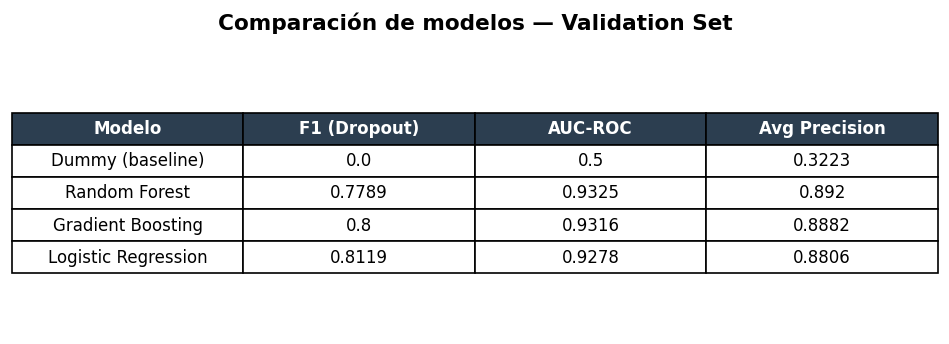

Fig 6 guardada.


In [6]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')

# Agregar fila del baseline
baseline_row = pd.DataFrame([{
    'Modelo': 'Dummy (baseline)',
    'F1 (Dropout)': round(f1_score(y_val, dummy.predict(X_val), pos_label=1), 4),
    'AUC-ROC': round(roc_auc_score(y_val, dummy.predict(X_val)), 4),
    'Avg Precision': round(average_precision_score(y_val, dummy.predict(X_val)), 4),
}])
df_tabla = pd.concat([baseline_row, df_resultados], ignore_index=True)

tabla = ax.table(
    cellText=df_tabla.values,
    colLabels=df_tabla.columns,
    cellLoc='center', loc='center'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.2, 1.6)

# Colorear encabezado
for j in range(len(df_tabla.columns)):
    tabla[0, j].set_facecolor('#2c3e50')
    tabla[0, j].set_text_props(color='white', fontweight='bold')

ax.set_title('Comparación de modelos — Validation Set', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}06_tabla_modelos.png', dpi=200, bbox_inches='tight')
plt.show()
print('Fig 6 guardada.')

## 6. Curvas de aprendizaje — modelo seleccionado

Las curvas de aprendizaje muestran si el modelo tiene **underfitting** (ambas curvas bajas) o **overfitting** (gap grande entre train y val). Usamos el modelo con mejor AUC-ROC en val.

Modelo seleccionado para curvas de aprendizaje: Random Forest


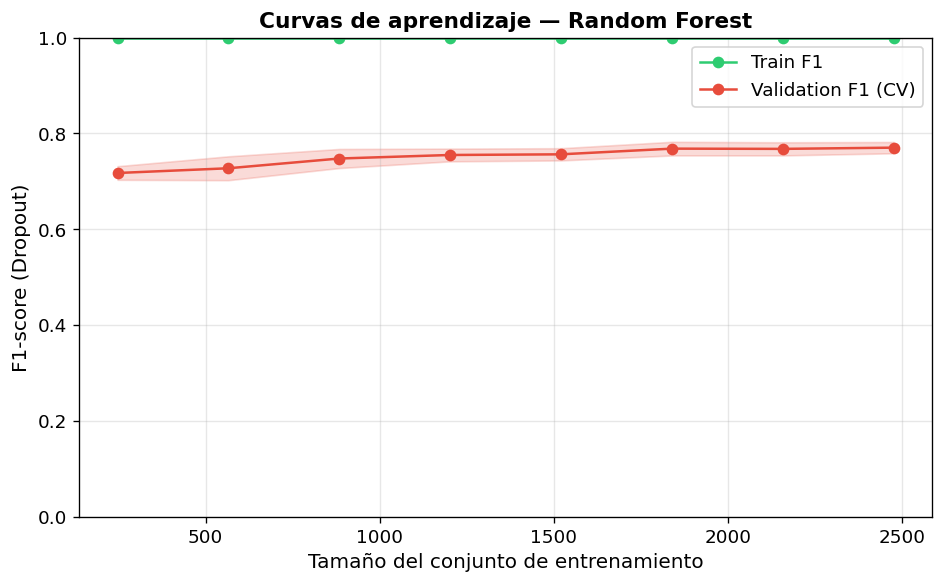

Fig 7 guardada.


In [7]:
mejor_nombre = df_resultados.iloc[0]['Modelo']
mejor_pipe   = pipelines[mejor_nombre]
print(f'Modelo seleccionado para curvas de aprendizaje: {mejor_nombre}')

train_sizes, train_scores, val_scores = learning_curve(
    mejor_pipe, X_train, y_train,
    cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#2ecc71', label='Train F1')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.2, color='#2ecc71')
ax.plot(train_sizes, val_mean, 'o-', color='#e74c3c', label='Validation F1 (CV)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.2, color='#e74c3c')

ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('F1-score (Dropout)')
ax.set_title(f'Curvas de aprendizaje — {mejor_nombre}', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}07_curvas_aprendizaje.png', dpi=200, bbox_inches='tight')
plt.show()
print('Fig 7 guardada.')

## 7. Evaluación final en TEST SET

> **Regla de oro:** el test set se usa **una sola vez**, al final. No se usó para seleccionar el modelo ni para ajustar hiperparámetros.

In [8]:
y_pred_test  = mejor_pipe.predict(X_test)
y_proba_test = mejor_pipe.predict_proba(X_test)[:, 1]

f1_test  = f1_score(y_test, y_pred_test, pos_label=1)
auc_test = roc_auc_score(y_test, y_proba_test)
ap_test  = average_precision_score(y_test, y_proba_test)

print(f'=== EVALUACIÓN FINAL — {mejor_nombre} — TEST SET ===')
print(classification_report(y_test, y_pred_test, target_names=['No Dropout', 'Dropout']))
print(f'F1 (Dropout):      {f1_test:.4f}')
print(f'AUC-ROC:           {auc_test:.4f}')
print(f'Avg Precision:     {ap_test:.4f}')

=== EVALUACIÓN FINAL — Random Forest — TEST SET ===
              precision    recall  f1-score   support

  No Dropout       0.88      0.94      0.91       451
     Dropout       0.85      0.73      0.79       213

    accuracy                           0.87       664
   macro avg       0.87      0.84      0.85       664
weighted avg       0.87      0.87      0.87       664

F1 (Dropout):      0.7879
AUC-ROC:           0.9335
Avg Precision:     0.8956


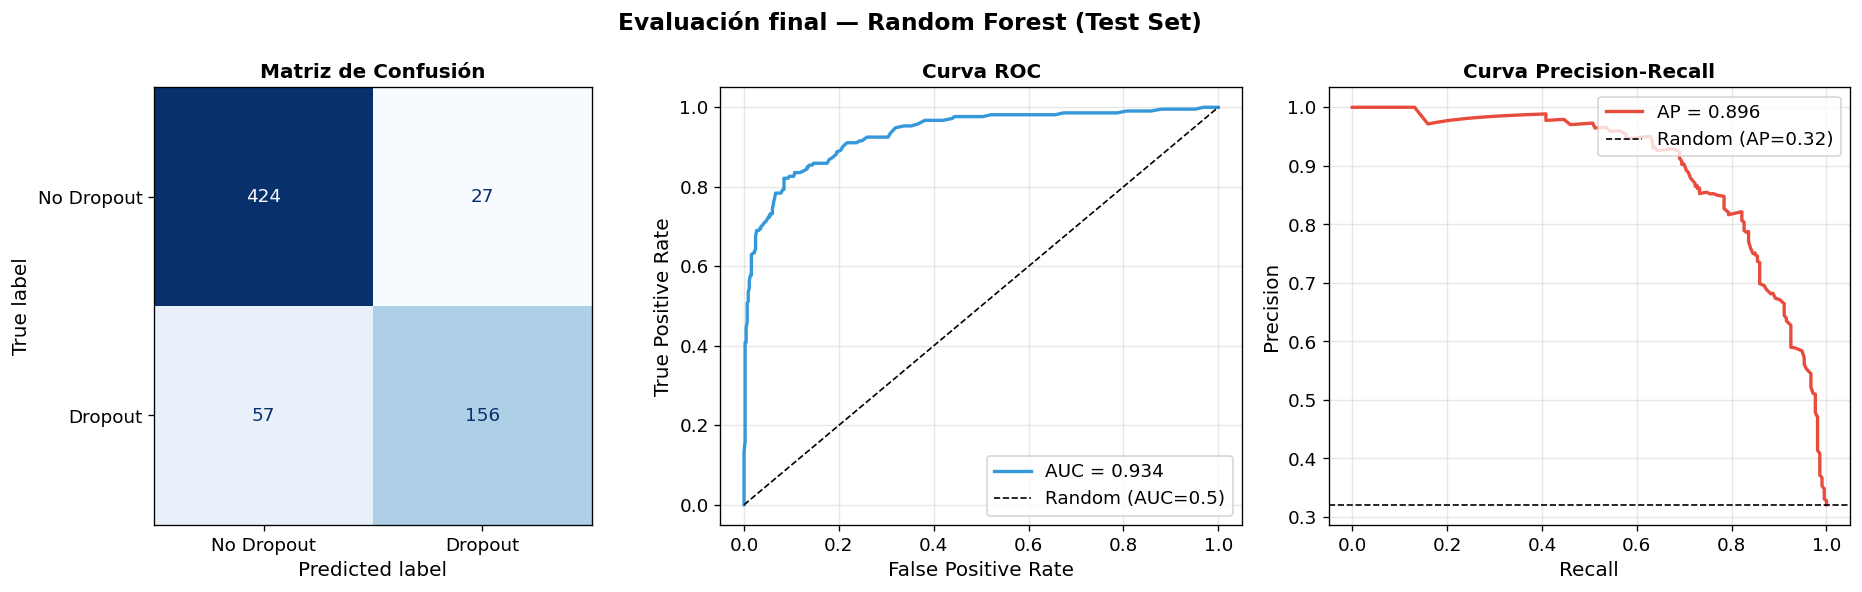

Fig 8 guardada.


In [9]:
# ── Figura 8: Matriz de confusión + Curva ROC + Curva PR ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Matriz de confusión ---
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Dropout', 'Dropout'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión', fontsize=12, fontweight='bold')

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
axes[1].plot(fpr, tpr, color='#3498db', lw=2, label=f'AUC = {auc_test:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# --- Curva Precision-Recall ---
precision, recall, _ = precision_recall_curve(y_test, y_proba_test)
baseline_pr = y_test.mean()
axes[2].plot(recall, precision, color='#e74c3c', lw=2, label=f'AP = {ap_test:.3f}')
axes[2].axhline(y=baseline_pr, color='k', linestyle='--', lw=1,
                label=f'Random (AP={baseline_pr:.2f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Curva Precision-Recall', fontsize=12, fontweight='bold')
axes[2].legend(loc='upper right')
axes[2].grid(alpha=0.3)

fig.suptitle(f'Evaluación final — {mejor_nombre} (Test Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}08_evaluacion_final.png', dpi=200, bbox_inches='tight')
plt.show()
print('Fig 8 guardada.')

## 8. Feature Importance

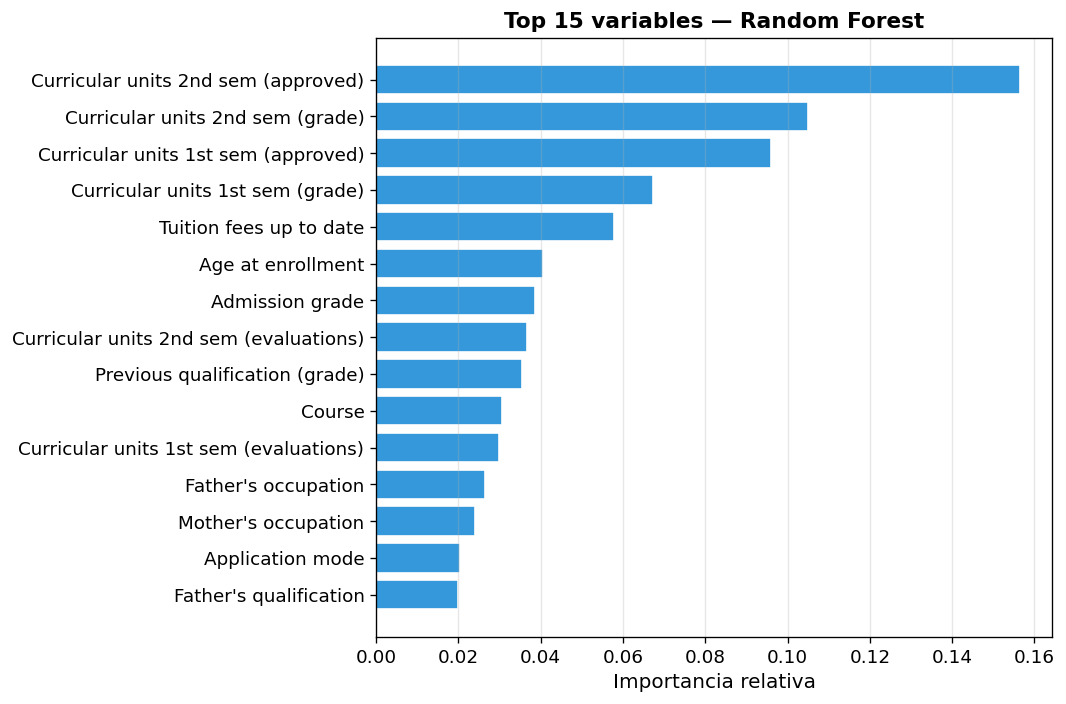

Fig 9 guardada.

Top 5 variables más predictivas:
                                feature  importance
30  Curricular units 2nd sem (approved)    0.156542
31     Curricular units 2nd sem (grade)    0.104979
24  Curricular units 1st sem (approved)    0.095866
25     Curricular units 1st sem (grade)    0.067210
16              Tuition fees up to date    0.057902


In [10]:
modelo_interno = mejor_pipe.named_steps['model']

if hasattr(modelo_interno, 'feature_importances_'):
    importancias = modelo_interno.feature_importances_
elif hasattr(modelo_interno, 'coef_'):
    importancias = np.abs(modelo_interno.coef_[0])
else:
    importancias = None

if importancias is not None:
    df_imp = pd.DataFrame({
        'feature':    X_train.columns,
        'importance': importancias
    }).sort_values('importance', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(df_imp['feature'][::-1], df_imp['importance'][::-1],
            color='#3498db', edgecolor='white')
    ax.set_xlabel('Importancia relativa')
    ax.set_title(f'Top 15 variables — {mejor_nombre}', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_PATH}09_feature_importance.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Fig 9 guardada.')
    print('\nTop 5 variables más predictivas:')
    print(df_imp.head())

## 9. Guardar modelo

In [11]:
ruta_modelo = os.path.join(MODELS_PATH, 'mejor_modelo.joblib')
joblib.dump(mejor_pipe, ruta_modelo)
print(f'Pipeline guardado en: {ruta_modelo}')

# Verificar que se puede cargar
pipe_cargado = joblib.load(ruta_modelo)
assert roc_auc_score(y_test, pipe_cargado.predict_proba(X_test)[:, 1]) == auc_test
print('Verificación OK — el modelo cargado reproduce los mismos resultados.')

Pipeline guardado en: ../models/checkpoints/mejor_modelo.joblib
Verificación OK — el modelo cargado reproduce los mismos resultados.


## 10. Resumen de resultados

In [12]:
print('=== RESUMEN FASE 2 ===')
print(f'Modelo ganador:        {mejor_nombre}')
print(f'F1 (Dropout) — Test:   {f1_test:.4f}')
print(f'AUC-ROC       — Test:  {auc_test:.4f}')
print(f'Avg Precision — Test:  {ap_test:.4f}')
print()
print('Checklist Fase 2:')
print('  [✓] Baseline establecido (DummyClassifier)')
print('  [✓] 3 modelos comparados con tabla de resultados')
print('  [✓] Pipeline con StandardScaler — sin data leakage')
print('  [✓] class_weight para manejo de desbalance')
print('  [✓] Curvas de aprendizaje generadas')
print('  [✓] Evaluación final en test set (F1, AUC-ROC, PR-curve)')
print('  [✓] Modelo guardado en models/checkpoints/')
print()
print('Próximo paso: notebook 04_llm_rag_agents.ipynb — Fase 3')

=== RESUMEN FASE 2 ===
Modelo ganador:        Random Forest
F1 (Dropout) — Test:   0.7879
AUC-ROC       — Test:  0.9335
Avg Precision — Test:  0.8956

Checklist Fase 2:
  [✓] Baseline establecido (DummyClassifier)
  [✓] 3 modelos comparados con tabla de resultados
  [✓] Pipeline con StandardScaler — sin data leakage
  [✓] class_weight para manejo de desbalance
  [✓] Curvas de aprendizaje generadas
  [✓] Evaluación final en test set (F1, AUC-ROC, PR-curve)
  [✓] Modelo guardado en models/checkpoints/

Próximo paso: notebook 04_llm_rag_agents.ipynb — Fase 3
